# Geospatial Analysis

## 0. Imports and Setup

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import geopandas as gpd
from pygris import tracts

## 1. Load HCV Data and Tract Shapefiles

In [31]:
df = pd.read_csv("data/clean_hcv_data.csv", dtype={"code": str})
df.head()

,program_label,program,entities,code,number_reported,rent_per_month,hh_income,tpoverty,treatment,year,post,poverty_indicator
0,Housing Choice Vouchers,3,TX Texas 113 Dallas County 48113000401,48113000401,39,297,11131,38,1,2014,0,1
1,Housing Choice Vouchers,3,TX Texas 113 Dallas County 48113000405,48113000405,17,268,10446,40,1,2014,0,1
2,Housing Choice Vouchers,3,TX Texas 113 Dallas County 48113000500,48113000500,25,202,8242,17,1,2014,0,0
3,Housing Choice Vouchers,3,TX Texas 113 Dallas County 48113000601,48113000601,17,336,12377,35,1,2014,0,1
4,Housing Choice Vouchers,3,TX Texas 113 Dallas County 48113000800,48113000800,123,326,11988,27,1,2014,0,0


In [32]:
# Download tract shapefiles for Dallas County (48113) and Harris County (48201).
# pygris caches locally after the first download.
dallas_shp = tracts(state="TX", county="113", year=2020, cache=True)
houston_shp = tracts(state="TX", county="201", year=2020, cache=True)

dallas_shp = dallas_shp[["GEOID", "geometry"]].rename(columns={"GEOID": "code"})
houston_shp = houston_shp[["GEOID", "geometry"]].rename(columns={"GEOID": "code"})

print(f"Dallas County: {len(dallas_shp)} tracts")
print(f"Harris County: {len(houston_shp)} tracts")

Using FIPS code '48' for input 'TX'
Using FIPS code '48' for input 'TX'
Dallas County: 645 tracts
Harris County: 1115 tracts


## 2. Classify Each Tract by Change Direction and Poverty Status

For every tract we compare its HCV household count in 2015 and 2022 and assign one of five categories:

| Category | Meaning |
|---|---|
| `hp_down` | High-poverty tract, HCV count decreased (voucher families leaving concentrated-poverty tracts) |
| `lp_up` | Low-poverty tract, HCV count increased (voucher families moving into lower-poverty tracts) |
| `hp_up` | High-poverty tract, HCV count increased (countervailing) |
| `lp_down` | Low-poverty tract, HCV count decreased (countervailing) |
| `no_data` | Tract suppressed in one or both years, or no change |

A tract is high-poverty if its average `tpoverty` across the two years is at least 30%, matching the `poverty_indicator` threshold used in Step 1.

Under the SAFMR policy hypothesis, Dallas should show many `hp_down` and `lp_up` tracts (deconcentration), while Houston should show a more balanced mix.

In [33]:
def classify_tracts(hcv_df, county_prefix):
    sub = hcv_df[hcv_df["code"].str.startswith(county_prefix)]
    y15 = sub[sub["year"] == 2015].set_index("code")[["number_reported", "tpoverty"]]
    y22 = sub[sub["year"] == 2022].set_index("code")[["number_reported", "tpoverty"]]

    all_codes = y15.index.union(y22.index)
    out = pd.DataFrame(index=all_codes)
    out["hcv_2015"] = y15["number_reported"]
    out["hcv_2022"] = y22["number_reported"]
    out["tpoverty_avg"] = pd.concat([y15["tpoverty"], y22["tpoverty"]], axis=1).mean(
        axis=1
    )
    out["delta"] = out["hcv_2022"] - out["hcv_2015"]
    out["high_poverty"] = out["tpoverty_avg"] >= 30

    def label(row):
        if pd.isna(row["delta"]) or row["delta"] == 0:
            return "no_data"
        if row["high_poverty"] and row["delta"] < 0:
            return "hp_down"
        if row["high_poverty"] and row["delta"] > 0:
            return "hp_up"
        if not row["high_poverty"] and row["delta"] < 0:
            return "lp_down"
        return "lp_up"

    out["category"] = out.apply(label, axis=1)
    return out.reset_index().rename(columns={"index": "code"})


dallas_cls = classify_tracts(df, "48113")
houston_cls = classify_tracts(df, "48201")

summary = (
    pd.DataFrame(
        {
            "Dallas": dallas_cls["category"].value_counts(),
            "Houston": houston_cls["category"].value_counts(),
        }
    )
    .reindex(["hp_down", "lp_up", "hp_up", "lp_down", "no_data"])
    .fillna(0)
    .astype(int)
)
summary

,Dallas,Houston
category,,
hp_down,37,54
lp_up,48,102
hp_up,15,41
lp_down,140,92
no_data,82,121


In [34]:
dallas_map = dallas_shp.merge(dallas_cls, on="code", how="left")
houston_map = houston_shp.merge(houston_cls, on="code", how="left")
dallas_map["category"] = dallas_map["category"].fillna("no_data")
houston_map["category"] = houston_map["category"].fillna("no_data")

## 3. Bivariate Choropleth: Where Did Vouchers Shift?

In [35]:
# Color scheme:
#   Blue = high-poverty tracts, Red = low-poverty tracts
#   Dark = change direction consistent with deconcentration
#   Light = opposite direction

category_colors = {
    "hp_down": "#08519c",  # dark blue   - high-poverty, decreasing  (POLICY SIGNAL)
    "hp_up": "#bdd7e7",  # light blue  - high-poverty, increasing
    "lp_up": "#cb181d",  # dark red    - low-poverty, increasing   (POLICY SIGNAL)
    "lp_down": "#fcae91",  # light red   - low-poverty, decreasing
    "no_data": "#e8e8e8",  # light gray  - no data
}

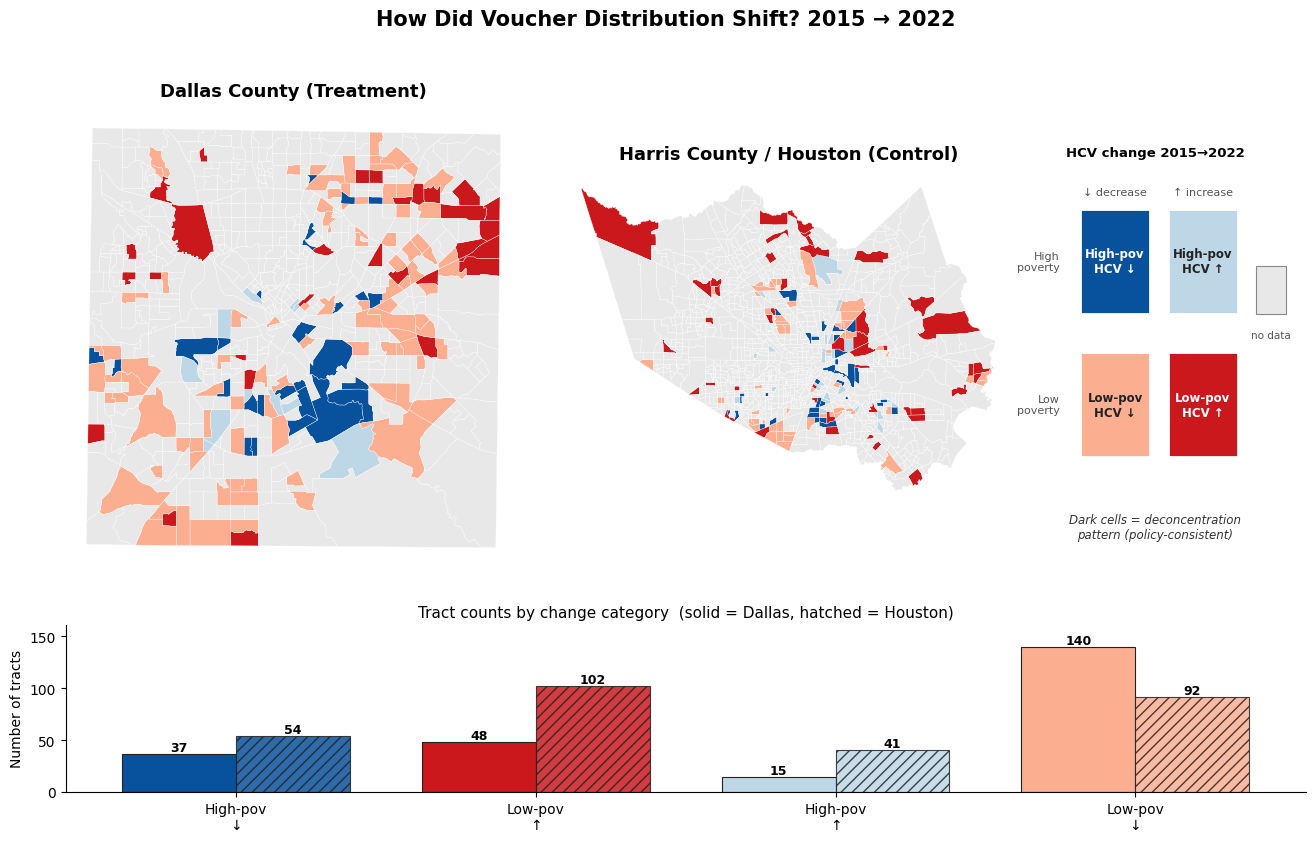

In [36]:
fig = plt.figure(figsize=(16, 9))
gs = GridSpec(
    2,
    3,
    width_ratios=[1, 1, 0.55],
    height_ratios=[1, 0.35],
    figure=fig,
    hspace=0.15,
    wspace=0.1,
)

ax_dallas = fig.add_subplot(gs[0, 0])
ax_houston = fig.add_subplot(gs[0, 1])
ax_legend = fig.add_subplot(gs[0, 2])
ax_bar = fig.add_subplot(gs[1, :])

# --- Maps ---
for ax, gdf, title in [
    (ax_dallas, dallas_map, "Dallas County (Treatment)"),
    (ax_houston, houston_map, "Harris County / Houston (Control)"),
]:
    for cat, color in category_colors.items():
        gdf[gdf["category"] == cat].plot(
            ax=ax,
            color=color,
            edgecolor="white",
            linewidth=0.25,
        )
    ax.set_title(title, fontsize=13, fontweight="bold", pad=8)
    ax.set_axis_off()

# --- Bivariate legend ---
ax_legend.set_xlim(0, 1)
ax_legend.set_ylim(0, 1)
ax_legend.axis("off")

legend_cells = [
    (0.10, 0.55, "#08519c", "High-pov\nHCV \u2193"),
    (0.45, 0.55, "#bdd7e7", "High-pov\nHCV \u2191"),
    (0.10, 0.25, "#fcae91", "Low-pov\nHCV \u2193"),
    (0.45, 0.25, "#cb181d", "Low-pov\nHCV \u2191"),
]
for x, y, color, label in legend_cells:
    ax_legend.add_patch(
        mpatches.Rectangle(
            (x, y), 0.28, 0.22, facecolor=color, edgecolor="white", linewidth=2
        )
    )
    ax_legend.text(
        x + 0.14,
        y + 0.11,
        label,
        ha="center",
        va="center",
        fontsize=8.5,
        color="white" if color in ("#08519c", "#cb181d") else "#222222",
        fontweight="bold",
    )

ax_legend.text(
    0.40,
    0.88,
    "HCV change 2015\u21922022",
    ha="center",
    fontsize=9.5,
    fontweight="bold",
)
ax_legend.text(0.24, 0.80, "\u2193 decrease", ha="center", fontsize=8, color="#555")
ax_legend.text(0.59, 0.80, "\u2191 increase", ha="center", fontsize=8, color="#555")
ax_legend.text(
    0.02, 0.66, "High\npoverty", ha="right", va="center", fontsize=8, color="#555"
)
ax_legend.text(
    0.02, 0.36, "Low\npoverty", ha="right", va="center", fontsize=8, color="#555"
)

ax_legend.text(
    0.40,
    0.08,
    "Dark cells = deconcentration\npattern (policy-consistent)",
    ha="center",
    fontsize=8.5,
    style="italic",
    color="#333",
)

ax_legend.add_patch(
    mpatches.Rectangle(
        (0.80, 0.55), 0.12, 0.10, facecolor="#e8e8e8", edgecolor="#888", linewidth=0.8
    )
)
ax_legend.text(0.86, 0.50, "no data", ha="center", fontsize=7.5, color="#555")

# --- Bar chart ---
cats_order = ["hp_down", "lp_up", "hp_up", "lp_down"]
cats_labels_short = [
    "High-pov\n\u2193",
    "Low-pov\n\u2191",
    "High-pov\n\u2191",
    "Low-pov\n\u2193",
]

x = np.arange(len(cats_order))
w = 0.38
dallas_counts = [summary.loc[c, "Dallas"] for c in cats_order]
houston_counts = [summary.loc[c, "Houston"] for c in cats_order]
bar_colors = [category_colors[c] for c in cats_order]

for i, (cnt, color) in enumerate(zip(dallas_counts, bar_colors)):
    ax_bar.bar(x[i] - w / 2, cnt, w, color=color, edgecolor="#222", linewidth=0.8)
for i, (cnt, color) in enumerate(zip(houston_counts, bar_colors)):
    ax_bar.bar(
        x[i] + w / 2,
        cnt,
        w,
        color=color,
        edgecolor="#222",
        linewidth=0.8,
        hatch="///",
        alpha=0.85,
    )

ymax = max(dallas_counts + houston_counts)
for i, (d, h) in enumerate(zip(dallas_counts, houston_counts)):
    ax_bar.text(
        x[i] - w / 2,
        d + ymax * 0.02,
        str(d),
        ha="center",
        fontsize=9,
        fontweight="bold",
    )
    ax_bar.text(
        x[i] + w / 2,
        h + ymax * 0.02,
        str(h),
        ha="center",
        fontsize=9,
        fontweight="bold",
    )

ax_bar.set_xticks(x)
ax_bar.set_xticklabels(cats_labels_short, fontsize=10)
ax_bar.set_ylabel("Number of tracts", fontsize=10)
ax_bar.set_title(
    "Tract counts by change category  (solid = Dallas, hatched = Houston)",
    fontsize=11,
    pad=6,
)
ax_bar.spines["top"].set_visible(False)
ax_bar.spines["right"].set_visible(False)
ax_bar.set_ylim(0, ymax * 1.15)

fig.suptitle(
    "How Did Voucher Distribution Shift? 2015 \u2192 2022",
    fontsize=15,
    fontweight="bold",
    y=0.98,
)
plt.show()

### Description

This figure shows how the geographic distribution of HCV households shifted between 2015 (pre-SAFMR) and 2022 (post-SAFMR) in Dallas County (treatment) and Harris County / Houston (control). Each tract is shaded by two things at once: whether its HCV household count went up or down across the two years, and whether it is a high-poverty tract (average `tpoverty` ≥ 30%).

Dark blue cells mark high-poverty tracts where voucher counts fell, and dark red cells mark low-poverty tracts where voucher counts rose — together these are the spatial signature expected under SAFMR deconcentration. Light cells mark the opposite direction in each row, and gray cells are tracts suppressed in at least one of the two years.

The bar chart summarizes the counts directly. The clearest policy-consistent signal is in the high-poverty row: Dallas has roughly 2.5 times as many high-poverty tracts losing vouchers as gaining them (37 vs 15), while Houston is much closer to even (54 vs 41). This is what we would expect if SAFMRs helped voucher families leave concentrated-poverty areas in Dallas.

The low-poverty row tells a more mixed story. In Dallas, low-poverty tracts losing vouchers (140) far outnumber those gaining vouchers (48), which runs against the simple deconcentration story. This is consistent with the overall decline in Dallas's HCV caseload seen in Section 2.4 — many tracts lost voucher households, and low-poverty tracts were no exception. Houston's low-poverty row is the opposite, with gains (102) exceeding losses (92).

Taken together, the figure supports the first half of the policy story (movement out of high-poverty tracts in Dallas) more clearly than the second half (movement into low-poverty tracts). A caveat: HUD suppresses tracts with fewer than 11 HCV households, so any tract whose count fell below 11 between the two years drops out of the sample entirely and appears in gray. Those dropouts are themselves suggestive of deconcentration but are not counted in the bars.
